# Applied Statistics: PyMC

Submitting: Gilad Mizrahi

## Exploring the Data

In [2]:
import pymc as pm
import arviz as az
import statsmodels.api as sm
import pingouin as pg
from scipy import stats
from sklearn.linear_model import Ridge
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = sm.datasets.get_rdataset("SAT", "mosaicData").data

REGIONS = {
    "Alabama": "East South Central",
    "Alaska": "Pacific",
    "Arizona": "Mountain",
    "Arkansas": "West South Central",
    "California": "Pacific",
    "Colorado": "Mountain",
    "Connecticut": "New England",
    "Delaware": "South Atlantic",
    "Florida": "South Atlantic",
    "Georgia": "South Atlantic",
    "Hawaii": "Pacific",
    "Idaho": "Mountain",
    "Illinois": "East North Central",
    "Indiana": "East North Central",
    "Iowa": "West North Central",
    "Kansas": "West North Central",
    "Kentucky": "East South Central",
    "Louisiana": "West South Central",
    "Maine": "New England",
    "Maryland": "South Atlantic",
    "Massachusetts": "New England",
    "Michigan": "East North Central",
    "Minnesota": "West North Central",
    "Mississippi": "East South Central",
    "Missouri": "West North Central",
    "Montana": "Mountain",
    "Nebraska": "West North Central",
    "Nevada": "Mountain",
    "New Hampshire": "New England",
    "New Jersey": "Middle Atlantic",
    "New Mexico": "Mountain",
    "New York": "Middle Atlantic",
    "North Carolina": "South Atlantic",
    "North Dakota": "West North Central",
    "Ohio": "East North Central",
    "Oklahoma": "West South Central",
    "Oregon": "Pacific",
    "Pennsylvania": "Middle Atlantic",
    "Rhode Island": "New England",
    "South Carolina": "South Atlantic",
    "South Dakota": "West North Central",
    "Tennessee": "East South Central",
    "Texas": "West South Central",
    "Utah": "Mountain",
    "Vermont": "New England",
    "Virginia": "South Atlantic",
    "Washington": "Pacific",
    "West Virginia": "South Atlantic",
    "Wisconsin": "East North Central",
    "Wyoming": "Mountain",
}

df.insert(1, "region", df["state"].map(REGIONS))

df

,state,region,expend,ratio,salary,frac,verbal,math,sat
0,Alabama,East South Central,4.405,17.2,31.144,8,491,538,1029
1,Alaska,Pacific,8.963,17.6,47.951,47,445,489,934
2,Arizona,Mountain,4.778,19.3,32.175,27,448,496,944
3,Arkansas,West South Central,4.459,17.1,28.934,6,482,523,1005
4,California,Pacific,4.992,24.0,41.078,45,417,485,902
5,Colorado,Mountain,5.443,18.4,34.571,29,462,518,980
6,Connecticut,New England,8.817,14.4,50.045,81,431,477,908
7,Delaware,South Atlantic,7.030,16.6,39.076,68,429,468,897
8,Florida,South Atlantic,5.718,19.1,32.588,48,420,469,889
9,Georgia,South Atlantic,5.193,16.3,32.291,65,406,448,854


In [3]:
df["region"].value_counts()

region
Mountain              8
South Atlantic        8
West North Central    7
New England           6
Pacific               5
East North Central    5
East South Central    4
West South Central    4
Middle Atlantic       3
Name: count, dtype: int64

In [4]:
df.describe()

,expend,ratio,salary,frac,verbal,math,sat
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,5.905260,16.858000,34.828920,35.240000,457.140000,508.780000,965.920000
std,1.362807,2.266355,5.941265,26.762417,35.175948,40.204726,74.820558
min,3.656000,13.800000,25.994000,4.000000,401.000000,443.000000,844.000000
25%,4.881750,15.225000,30.977500,9.000000,427.250000,474.750000,897.250000
50%,5.767500,16.600000,33.287500,28.000000,448.000000,497.500000,945.500000
75%,6.434000,17.575000,38.545750,63.000000,490.250000,539.500000,1032.000000
max,9.774000,24.300000,50.045000,81.000000,516.000000,592.000000,1107.000000


### AI,
* What is the SAT exam in one sentence?
* What are the possible exam scores? Give a percentile table.

### Answer

##### What is the SAT?
The SAT is a standardized, multiple-choice test used primarily by U.S. colleges to assess a high school student's readiness for higher education, covering Reading/Writing and Math.

##### Possible Scores
The SAT is scored on a scale of 400–1600, combining two section scores of 200–800 each:

* Evidence-Based Reading and Writing (EBRW): 200–800
* Math: 200–800

##### Approximate Percentile Table

| Composite Score | Approx. Percentile |
|---|---|
| 1600 | 99+ |
| 1500 | 98 |
| 1400 | 94 |
| 1300 | 87 |
| 1200 | 76 |
| 1100 | 62 |
| 1000 | 45 |
| 900 | 28 |
| 800 | 13 |
| 700 | 4 |




| Variable | Description                                                                                  |
|----------|----------------------------------------------------------------------------------------------|
| state    | a factor with names of each state                                                            |
| expend   | expenditure per pupil in average daily attendance in public elementary and secondary schools |
| ratio    | average pupil/teacher ratio in public elementary and secondary schools                       |
| salary   | estimated average annual salary of teachers in public elementary and secondary schools       |
| frac     | percentage of all eligible students taking the SAT                                           |
| verbal   | average verbal SAT score                                                                     |
| math     | average math SAT score                                                                       |
| sat      | average total SAT score                                                                      |

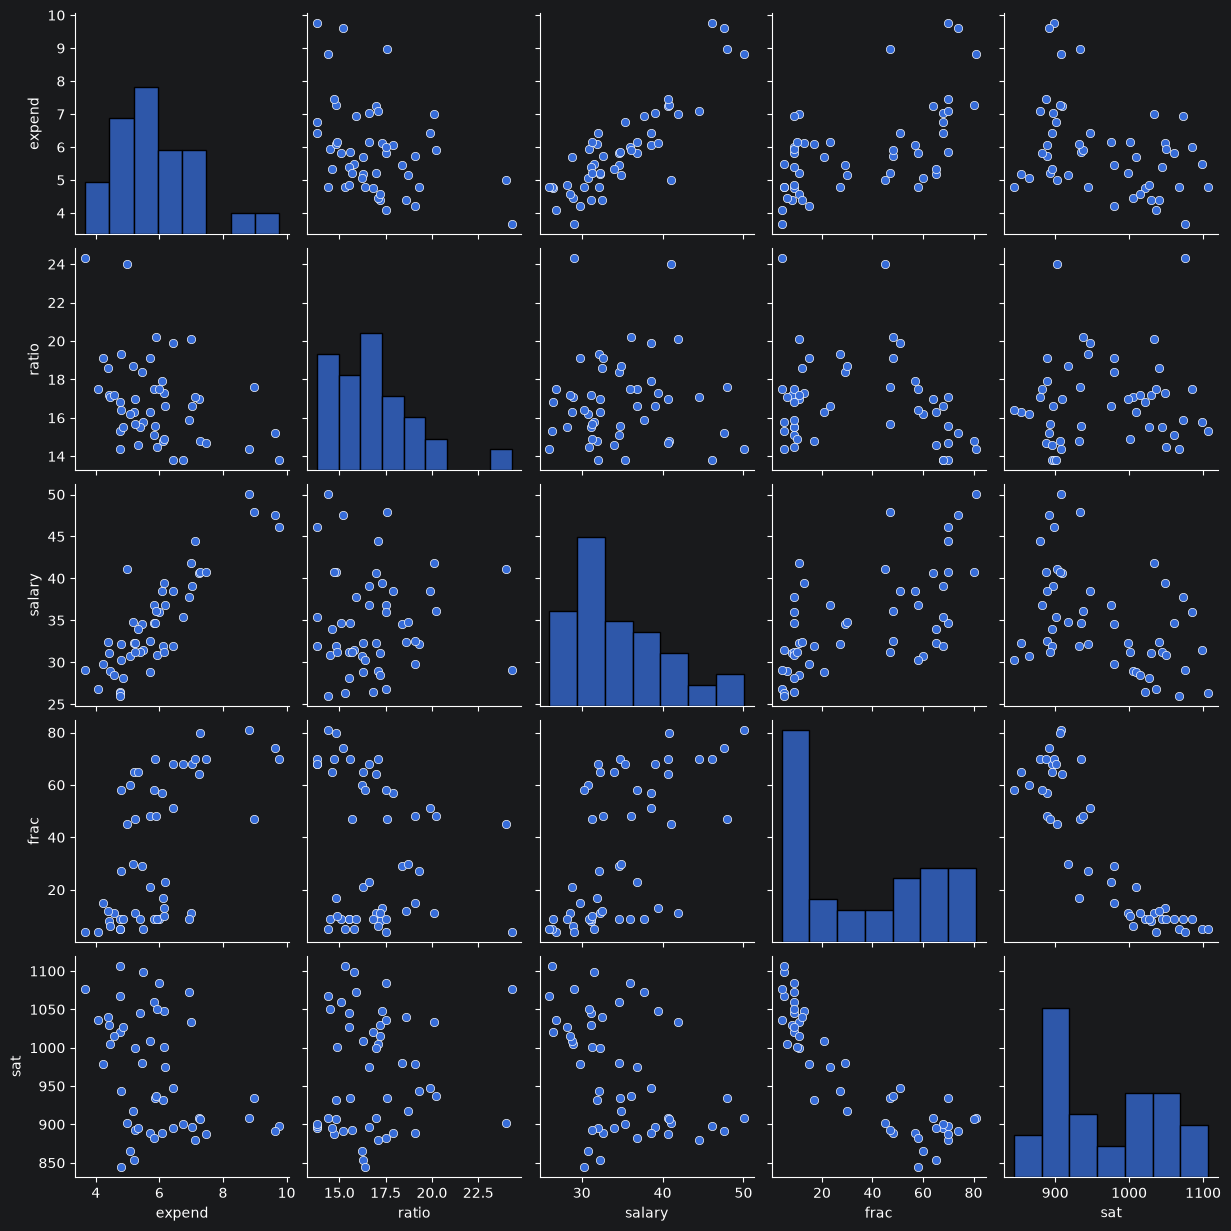

In [5]:
sns.pairplot(df.drop(columns=["verbal", "math"])).tight_layout()

### Simpson's Paradox?

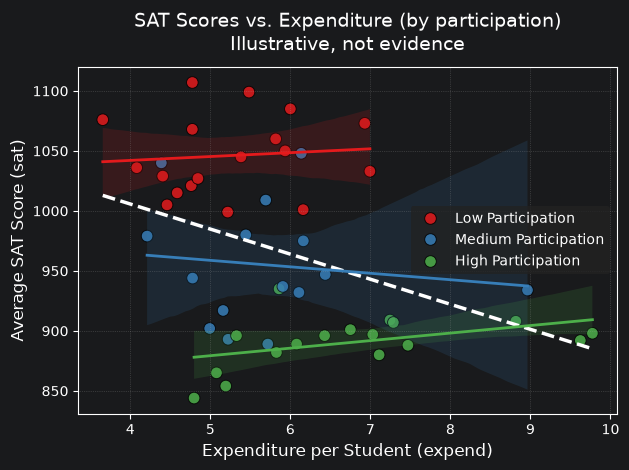

In [6]:
tiers = ["Low Participation", "Medium Participation", "High Participation"]

df["frac_tier"] = pd.qcut(df["frac"], q=3, labels=tiers)

# 1. Scatter points
sns.scatterplot(
    data=df,
    x="expend",
    y="sat",
    hue="frac_tier",
    palette="Set1",
    s=70,
    edgecolor="black",
    alpha=0.85,
)

# 2. Overall Naive Trend (No CI clutter)
sns.regplot(
    data=df,
    x="expend",
    y="sat",
    scatter=False,
    ci=None,
    line_kws={
        "linestyle": "--",
        "color": "white",
        "linewidth": 2.5,
        "label": "Pooled Trend (Naive)",
    },
)

# 3. Stratified Trends
colors = sns.color_palette("Set1", 3)

for tier, color in zip(tiers, colors):
    sns.regplot(
        data=df[df["frac_tier"] == tier],
        x="expend",
        y="sat",
        scatter=False,
        line_kws={"color": color, "linewidth": 2, "label": f"{tier} Trend"},
    )

plt.title(
    "SAT Scores vs. Expenditure (by participation)\nIllustrative, not evidence",
    fontsize=14,
    pad=12,
)
plt.xlabel("Expenditure per Student (expend)", fontsize=12)
plt.ylabel("Average SAT Score (sat)", fontsize=12)
plt.legend(frameon=True, facecolor="#222222", edgecolor="none")
plt.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

### AI,

* Can Simpson's paradox occur on a confounding variable that is not grouped/clustered?
* Show me the equation to when it actually happens

#### Answer

##### Yes — grouping is not required

Simpson's Paradox is often shown with categorical confounders (like your participation groups) because it's visually intuitive, but the mechanism is really about confounding/omitted-variable bias, which applies just as well to a continuous confounder. Grouping is just one special case (equivalent to using a categorical/dummy variable for the confounder).

##### The general equation

Suppose the true relationship between Y and X, controlling for confounder Z, is:

$$ Y = \beta_0 + \beta_1 X + \beta_2 Z + \varepsilon $$

If you ignore Z and regress Y on X alone, the marginal (pooled) slope you estimate is:

$$ \beta_1^* = \beta_1 + \beta_2 \cdot \gamma $$

where $\gamma = \frac{\text{Cov}\left(X, Z\right)}{\text{Var}\left(X\right)}$ — i.e., the slope you'd get regressing Z on X (how strongly the confounder moves with X).

This is the classic omitted-variable bias formula.

##### When Simpson's Paradox (sign reversal) actually happens

The pooled slope $\beta_1^*$ flips sign relative to the true within-group slope $\beta_1$ when:

$\text{sgn}\left(\beta_2 \cdot \gamma\right) \neq \text{sgn}\left(\beta_1\right)$ AND $|\beta_2 \cdot \gamma| > |\beta_1|$

In words: the confounder's effect on Y ($\beta_2$), amplified by how strongly it's correlated with X ($\gamma$), has to be large enough and in the opposite direction to overpower and reverse the true effect.

In [7]:
corr_cols = ["sat", "expend", "frac"]
marginal_corr = df[corr_cols].corr(method="pearson")
print("Marginal (Pearson) correlations:")
marginal_corr.round(3)

Marginal (Pearson) correlations:


,sat,expend,frac
sat,1.000,-0.381,-0.887
expend,-0.381,1.000,0.593
frac,-0.887,0.593,1.000


`sat-expend` is negative, but does not correlate strongly . `frac` strongly correlates with `expend` and `sat`

### AI,

* What is a partial correlation? What does it differ from a regular Pearson correlation table?
* Show the brief formula

#### Answer

A **Pearson correlation** between two variables, X and Y, measures their raw linear association — but that association can be inflated or distorted by other variables that influence both X and Y.

A **partial correlation** measures the linear association between X and Y *after removing (controlling for) the linear effect of one or more other variables* (call them Z).

**Why it matters:** if X and Y are both driven by a common factor Z, their Pearson correlation can look strong even though X and Y have little direct relationship. Partial correlation strips that shared influence out, so what's left reflects the relationship between X and Y that isn't explained by Z.

##### Key differences from a regular correlation table

| | Pearson correlation | Partial correlation |
|---|---|---|
| What it measures | Raw association between two variables | Association between two variables, controlling for others |
| Confounders | Ignored — can inflate/deflate results | Removed (linearly) before computing correlation |
| Table interpretation | Each cell is a standalone bivariate relationship | Each cell reflects a "net" relationship, holding all other variables in the set constant |

##### Formula

For three variables X, Y, Z, the partial correlation of X and Y controlling for Z is:

$$
r_{XY \cdot Z} = \frac{r_{XY} - r_{XZ}\,r_{YZ}}{\sqrt{(1-r_{XZ}^2)(1-r_{YZ}^2)}}
$$

where $r_{XY}$, $r_{XZ}$, $r_{YZ}$ are the ordinary Pearson correlations between each pair.

Equivalently — and how this generalizes to many control variables — the process is:

1. Regress X on Z, and keep the residuals.
2. Regress Y on Z, and keep the residuals.
3. Compute the Pearson correlation between those two sets of residuals.

That residual correlation *is* the partial correlation.

In [8]:
def partial_corr(df, x, y, control):
    """Partial correlation between x and y, controlling for `control` (single covariate)."""
    # Residualize x on control
    slope_x, intercept_x, *_ = stats.linregress(df[control], df[x])
    resid_x = df[x] - (slope_x * df[control] + intercept_x)

    # Residualize y on control
    slope_y, intercept_y, *_ = stats.linregress(df[control], df[y])
    resid_y = df[y] - (slope_y * df[control] + intercept_y)

    r, p = stats.pearsonr(resid_x, resid_y)
    return r, p


r_partial, p_partial = partial_corr(df, x="expend", y="sat", control="frac")
r_marginal, p_marginal = stats.pearsonr(df["expend"], df["sat"])

summary = pd.DataFrame(
    {
        "Correlation type": [
            "Marginal (sat vs expend)",
            "Partial (sat vs expend | frac)",
        ],
        "r": [r_marginal, r_partial],
        "p-value": [p_marginal, p_partial],
    }
)

summary.round(4)

,Correlation type,r,p-value
0,Marginal (sat vs expend),-0.3805,0.0064
1,Partial (sat vs expend | frac),0.3906,0.0050


### AI,

* What is partial regression? Does it relate to partial correlation?
* Show the formula for 2 predictors

#### Answer

**Partial regression** is the regression-based analogue of partial correlation: it isolates the relationship between one predictor and the outcome, after removing the linear influence of the other predictors on *both* variables.

##### How it relates to partial correlation

Recall the partial correlation trick: regress X on Z, regress Y on Z, take the residuals from each, then correlate the residuals. Partial regression does the same thing, but instead of just correlating the residuals, you **regress one set of residuals on the other** — which gives you a slope, not just a correlation coefficient.

##### Why it's useful: the added variable plot

In multiple regression, $Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \varepsilon$, the coefficient $\beta_1$ already represents the effect of $X_1$ on Y holding the other predictors constant. Partial regression makes this visible and diagnosable via the **added variable plot** (a.k.a. partial regression plot), built like this:

1. Regress Y on all predictors *except* $X_1$ → keep the residuals ($e_Y$).
2. Regress $X_1$ on all the other predictors → keep the residuals ($e_{X_1}$).
3. Plot $e_Y$ against $e_{X_1}$, and fit a line.

The slope of that line **equals** $\beta_1$ from the full multiple regression — and the scatter shows the "pure" relationship between $X_1$ and Y with everything else's influence stripped out of both variables.

##### Formula (two-predictor case)

For $Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \varepsilon$:

$$
\beta_1 = \frac{\text{Cov}(e_Y, e_{X_1})}{\text{Var}(e_{X_1})}
$$

where $e_Y$ and $e_{X_1}$ are the residuals described above.

##### Practical value of added variable plots

They let you visually check things a coefficient alone can't show:
- Whether the relationship is actually linear
- Whether one or two influential points are driving the estimated slope
- Outliers that a simple X-vs-Y scatterplot would hide, since they only become extreme once other variables are accounted for

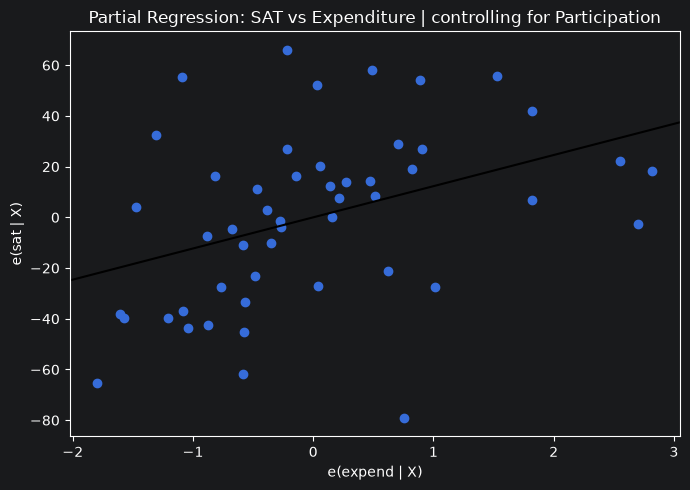

In [9]:
fig = plt.figure(figsize=(7, 5))
sm.graphics.plot_partregress(
    endog="sat",
    exog_i="expend",
    exog_others=["frac"],
    data=df,
    obs_labels=False,
    ax=fig.add_subplot(111),
)
plt.title("Partial Regression: SAT vs Expenditure | controlling for Participation")
plt.tight_layout()
plt.show()

#### What about the coefficient formula?

In [10]:
naive = sm.OLS(df["sat"], sm.add_constant(df[["expend"]])).fit()
adjusted = sm.OLS(df["sat"], sm.add_constant(df[["expend", "frac"]])).fit()

print(naive.summary())
print(adjusted.summary())

                            OLS Regression Results                            
Dep. Variable:                    sat   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     8.128
Date:                Wed, 12 Aug 2026   Prob (F-statistic):            0.00641
Time:                        10:34:37   Log-Likelihood:                -282.29
No. Observations:                  50   AIC:                             568.6
Df Residuals:                      48   BIC:                             572.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1089.2937     44.390     24.539      0.0

### AI,

* What do you say about these results (before and after adjustment)?: <C&P>
* Is there anything we should watch out for? Why is the condition number much higher?

#### Answer

##### What to watch out for
1. Sign reversal is a red flag for omitted variables, not for the newer model being automatically "correct." You should ask whether there are still other confounders missing (e.g., median income, teacher salaries, class size, urban/rural mix) that could flip or change the coefficients again.
2. Correlation between `expend` and `frac` is exactly why the coefficient on expend changed so much between models — this is a sign of multicollinearity, even if not severe enough to make estimates unusable.
3. Small sample (n = 50) — likely state-level data. With only 50 observations, results are sensitive to a few influential points/outliers. Worth checking leverage/Cook's distance.
4. Standard errors are "nonrobust" — homoskedasticity is assumed. Given this is likely cross-sectional state data, heteroskedasticity is plausible; robust (HC) standard errors would be a good check.
5. Causality: this is observational data. Even with the better-specified model, "expend causes higher SAT scores" isn't established — reverse causality or confounding (e.g., wealthier states spend more and have systematically different student populations) is still possible.

##### Why the condition number jumped (27.9 → 215)

The condition number measures how collinear/ill-scaled the predictor matrix is. It rose sharply because:

* `expend` and `frac` are correlated with each other, and possibly both correlated with the constant term if not centered — adding a second correlated regressor increases the condition number almost mechanically.
* Different scales: `expend` is probably in thousands of dollars (e.g., 3–9) while `frac` is a percentage (e.g., 0–100). When predictors have very different scales and are also correlated, the design matrix becomes more ill-conditioned.
* A condition number of 215 is still well below common danger thresholds (~30 is "moderate," >100 "may indicate a problem," but the classic rule of thumb from Belsley et al. is that condition numbers above ~30 warrant a look and above ~1000 are more clearly problematic). 215 is worth noting but not alarming on its own — especially since standard errors on both coefficients are still quite tight relative to the estimates. Still, if you add more correlated regressors, you'd want to check variance inflation factors (VIFs) directly rather than relying only on the condition number.

**Bottom line**: Model 2 is clearly the better-specified model — it fits far better and resolves an economically implausible negative-spending effect — but the sign flip should make you cautious about remaining omitted variables and correlated predictors rather than treating this as the final word.

In [11]:
print(
    f"Naive expend coef:    {naive.params['expend']:.3f}  (p={naive.pvalues['expend']:.3f})"
)
print(
    f"Adjusted expend coef: {adjusted.params['expend']:.3f}  (p={adjusted.pvalues['expend']:.3f})"
)

Naive expend coef:    -20.892  (p=0.006)
Adjusted expend coef: 12.287  (p=0.006)


In our case:
$$ \beta_1^* = -20.892, \beta_1 = 12.287 \implies \beta_2 \cdot \gamma = -33.179 $$

## Frequentist Approach

A collection of frequentist methods; referred to in later sections. Using the same "tiered" frac from earlier.

### AI,

* I would like to use a t-test between independent groups, but am not able to confirm the assumption of equal variance. What can I do?
* Explain the formula for Welch's t-test

#### Answer

##### When variances aren't equal: use Welch's t-test

The standard (Student's) independent-samples t-test assumes equal population variances (homogeneity of variance). If you can't confirm that assumption — or a test like Levene's or Bartlett's tells you the variances differ significantly — your best option is Welch's t-test.

Welch's t-test is essentially a modified version of the t-test that doesn't require equal variances. A few practical points:

* It uses each group's own variance separately, rather than pooling them.
* It adjusts the degrees of freedom to account for the unequal variances, which usually results in a non-integer df.
* It performs about as well as the standard t-test when variances are equal, so there's little downside to using it by default. In fact, many statisticians recommend using Welch's t-test as the default choice for two-sample comparisons, rather than testing for equal variance first and then picking between tests.

##### The Formula for Welch's t-test

**Test statistic:**

$$ t = \frac{\left(\bar{X}_2 - \bar{X}_2\right)}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}} $$

Where:
- $\bar{X}_1, \bar{X}_2$ = sample means of group 1 and group 2
- $s_1^2, s_2^2$ = sample variances of group 1 and group 2
- $n_1, n_2$ = sample sizes of group 1 and group 2

Notice the denominator: instead of pooling the two variances into one shared
estimate (as Student's t-test does), Welch's test adds the two groups'
variance-over-n terms separately. This is what makes it robust to unequal
variances.

**Degrees of freedom (Welch–Satterthwaite equation):**

$$ df = \frac{\left(\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}\right)^2}{\frac{\left(s_1^2/n_1\right)^2}{n_1-1} + \frac{\left(s_2^2/n_2\right)^2}{n_2-1}} $$

This formula estimates an "effective" degrees of freedom that's generally
lower than what you'd get with the pooled-variance approach
(df = n₁ + n₂ - 2), especially when variances and/or sample sizes differ
a lot between groups. Since it's typically not a whole number, it's often
rounded down, or software just uses the fractional value directly when
computing the p-value.

**Interpretation:** once you have t and df, you compare against the
t-distribution as usual to get your p-value or critical value — the
mechanics of hypothesis testing don't change, only how t and df are computed.

### Equal means?

In [12]:
high = df.loc[df["frac_tier"] == "High Participation", "sat"]
low = df.loc[df["frac_tier"] == "Low Participation", "sat"]

t_stat, p_val = stats.ttest_ind(
    high, low, equal_var=False
)  # Welch's t-test (safer default)
print(f"t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
print(f"High mean: {high.mean():.2f}, Low mean: {low.mean():.2f}")

t-test: t = -16.470, p = 0.0000
High mean: 890.65, Low mean: 1046.06


$ p < 0.005 $, reject equal means...

### Normal Residuals?

$$ \begin{align}
\text{sat} &= \beta_0 + \beta_1 X_\text{expand} + \beta_2 X_\text{frac} + \varepsilon\\
\varepsilon &\stackrel{?}{\sim} N(0, \sigma^2)
\end {align}$$

In [13]:
resid = adjusted.resid

shapiro_stat, shapiro_p = stats.shapiro(resid)
print(f"Shapiro-Wilk: W = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")

Shapiro-Wilk: W = 0.9850, p = 0.7720


### AI,

* Shapiro-Wilk test gave `W = 0.9850, p = 0.7720` for $N=50$. Is there anything we need to doubt?
* What other test for normality can we do? specifically, non-parametric one

#### Answer

##### On the Shapiro-Wilk result

A W of 0.985 with p = 0.772 (N=50) gives you no evidence against normality — you fail to reject the null hypothesis that residuals are normally distributed. That's a genuinely reassuring result, not a borderline one.

A few things worth keeping in mind, though, not because the test is wrong, but because "fail to reject normality" is a limited claim:

Absence of evidence isn't proof of normality. With N=50, Shapiro-Wilk has decent but not great power — it's good at catching skewness and moderate departures, weaker at catching heavy/light tails or subtle multimodality. A p of 0.77 says the test found nothing suspicious, not that the residuals are guaranteed Gaussian.
It only tests the marginal distribution shape, not other OLS assumptions — homoscedasticity, independence, linearity, absence of influential outliers. A single well-behaved-looking residual distribution can still hide a violated assumption elsewhere (e.g., variance increasing with fitted values).
Complement it with a visual check — a QQ-plot of residuals against theoretical normal quantiles. This is honestly more informative than the p-value alone, since it shows where any departure would be (tails vs. center) rather than just yes/no.
If you have any influential points or leverage outliers, it's worth checking those separately (Cook's distance, leverage plots) since a handful of points can pass a normality test while still distorting inference.

So: nothing to doubt in the result itself, just don't treat it as the only diagnostic you need to run.

##### Other nonparametric normality tests
* **Kolmogorov–Smirnov test (with Lilliefors correction)** — compares the empirical CDF of residuals to a normal CDF. You need the Lilliefors correction because standard KS critical values assume the mean/variance are known, not estimated from the same data (as they are here since you fit OLS).
* Anderson–Darling test — also compares empirical vs. theoretical CDF, but weights the tails more heavily than KS does. Often preferred over KS for normality specifically because it's more sensitive to tail deviations, which matter a lot for inference (SEs, CIs).
* Cramér–von Mises test — similar family to KS/AD (EDF-based), less commonly used but sometimes reported alongside AD.
* Jarque–Bera test — technically uses skewness and kurtosis moments rather than being fully distribution-free, so it's not strictly "nonparametric" in the same sense as the EDF-based tests above, but it's a common companion test in regression contexts and worth mentioning if you're deciding what to run alongside Shapiro-Wilk.

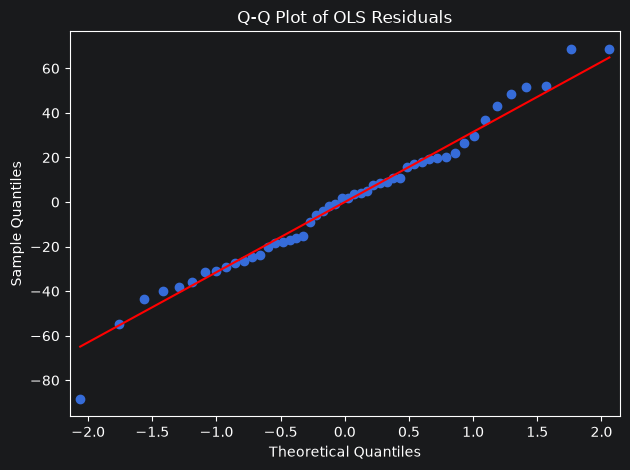

In [14]:
fig = sm.qqplot(resid, line="s")
plt.title("Q-Q Plot of OLS Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.tight_layout()
plt.show()

#### Non-parametric alternative

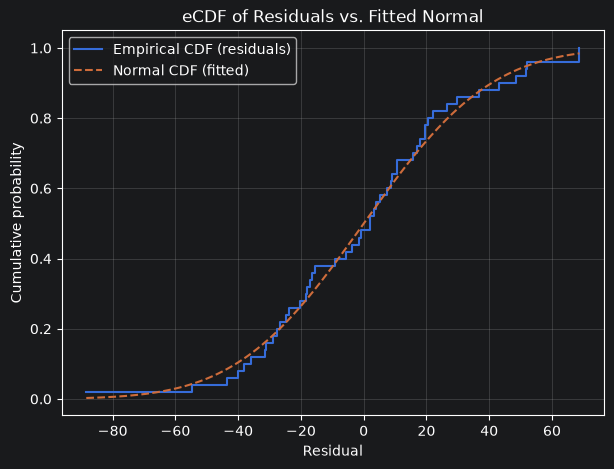

Lilliefors test: D = 0.0660, p = 0.8418


In [15]:
from statsmodels.stats._lilliefors import lilliefors

x_sorted = np.sort(resid)
ecdf_y = np.arange(1, len(x_sorted) + 1) / len(x_sorted)

# Theoretical normal CDF for comparison, same mean/std as residuals
mu, sigma = resid.mean(), resid.std()
x_theory = np.linspace(x_sorted.min(), x_sorted.max(), 200)
y_theory = stats.norm.cdf(x_theory, mu, sigma)

plt.figure(figsize=(7, 5))
plt.step(x_sorted, ecdf_y, label="Empirical CDF (residuals)", where="post")
plt.plot(x_theory, y_theory, "--", label="Normal CDF (fitted)")
plt.xlabel("Residual")
plt.ylabel("Cumulative probability")
plt.title("eCDF of Residuals vs. Fitted Normal")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

lstat, lp = lilliefors(resid, dist="norm")
print(f"Lilliefors test: D = {lstat:.4f}, p = {lp:.4f}")

### Region Difference?

### AI,

* What are the assumptions for a one-way ANOVA test?
* How can we check for equal variances? What can we do if that assumption is violated?

#### Answer

##### Assumptions for One-Way ANOVA
1. Independence of observations — Observations within and between groups must be independent of each other (e.g., no repeated measures on the same subject, no clustering). This is usually ensured by study design, not tested statistically.
2. Normality — The residuals (or the response variable within each group) should be approximately normally distributed. ANOVA is fairly robust to moderate violations, especially with larger and roughly equal sample sizes.
3. Homogeneity of variances (homoscedasticity) — The variance of the response variable should be roughly equal across all groups.
4. Random sampling — Data should come from a random sample of the population(s) of interest.
5. (Implicit) Continuous/interval-level dependent variable and a categorical independent variable with 2+ groups.
6. Checking Equal Variances

##### Visual methods:

Boxplots or strip plots of the response by group — look for similarly sized spreads
Residuals vs. fitted values plot — look for a "fanning" or "funneling" pattern (bad sign)

Formal tests:

**Levene's test** — most commonly recommended; tests equality of variances based on absolute deviations from group medians (or means). Robust to non-normality.
Bartlett's test — more powerful than Levene's, but sensitive to departures from normality, so it's only reliable if the normality assumption holds.
Brown-Forsythe test — a variant of Levene's using medians; very robust.

Rule of thumb: if the ratio of largest to smallest group standard deviation is less than about 2 (or variance ratio less than 4), ANOVA is often considered reasonably robust even without a formal test — but this is just a heuristic, not a substitute for checking.

##### If the Equal-Variance Assumption Is Violated

You have several options:

* **Welch's ANOVA** — the most common fix. It's a variant of one-way ANOVA that does not assume equal variances (adjusts the degrees of freedom instead). Recommended as the default replacement in many modern textbooks, especially with unequal group sizes.
* Transform the data — e.g., log, square root, or Box-Cox transformation can sometimes stabilize variance (and may also help with normality).
* Use a non-parametric alternative — the Kruskal-Wallis test compares group distributions using ranks rather than raw values, and is less sensitive to variance inequality (though it's really testing distributions/medians more generally, not means).
* Weighted least squares / generalized least squares — model heteroscedasticity explicitly rather than assuming it away.
* Games-Howell post-hoc test — if you proceed with unequal variances and need pairwise comparisons after significance, use Games-Howell instead of Tukey's HSD, since Tukey's assumes equal variances.

In [16]:
groups = [group["sat"].values for name, group in df.groupby("region")]
levene_stat, levene_p = stats.levene(*groups)
print(f"Levene's test: W = {levene_stat:.4f}, p = {levene_p:.4f}")

pg.welch_anova(df, dv="sat", between="region")

Levene's test: W = 1.2560, p = 0.2927


,Source,ddof1,ddof2,F,p_unc,np2
0,region,8,15.044199,43.858372,4.779868e-09,0.759775


### TODO ADD INFO

In [17]:
contingency = pd.crosstab(df["region"], df["frac_tier"])

contingency

frac_tier,Low Participation,Medium Participation,High Participation
region,,,
East North Central,2,2,1
East South Central,3,1,0
Middle Atlantic,0,0,3
Mountain,3,5,0
New England,0,0,6
Pacific,0,4,1
South Atlantic,0,2,6
West North Central,7,0,0
West South Central,3,1,0


In [18]:
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square: χ² = {chi2:.3f}, p = {chi_p:.4f}, dof = {dof}")
print("Min expected count:", expected.min())


Chi-square: χ² = 55.257, p = 0.0000, dof = 16
Min expected count: 0.9


In [19]:
import numpy as np
from scipy.stats import chi2_contingency


def chi2_stat(table):
    chi2, _, _, _ = chi2_contingency(table)
    return chi2


observed_stat = chi2_stat(contingency)

n_sim = 10000
rng = np.random.default_rng(42)
sim_stats = np.empty(n_sim)

region_vals = df["region"].values
tier_vals = df["frac_tier"].values

for i in range(n_sim):
    shuffled_tier = rng.permutation(tier_vals)
    sim_table = pd.crosstab(pd.Series(region_vals), pd.Series(shuffled_tier))
    sim_stats[i] = chi2_stat(sim_table)

perm_p = (sim_stats >= observed_stat).mean()
print(f"Permutation-based p-value: {perm_p:.4f}")

Permutation-based p-value: 0.0000


### CI

In [20]:
conf_int = adjusted.conf_int(alpha=0.05)
print("95% CI for expend coefficient:")
print(conf_int.loc["expend"])

95% CI for expend coefficient:
0     3.788291
1    20.784746
Name: expend, dtype: float64


Bootstrap

Bootstrap 95% CI for expend coefficient: [4.932, 21.326]
Bootstrap mean: 12.706
Original 95% CI for expend coefficient: [3.788, 20.785]
Original sample estimate:  12.287


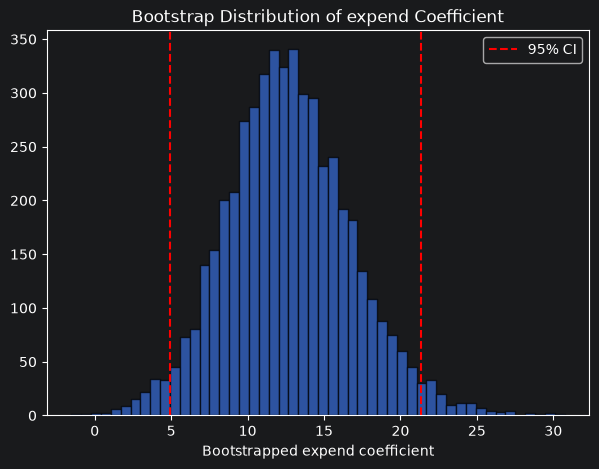

In [21]:
n_boot = 5000
boot_coefs = np.empty(n_boot)

rng = np.random.default_rng(42)

for i in range(n_boot):
    sample = df.sample(n=len(df), replace=True, random_state=rng.integers(1e9))
    X_boot = sm.add_constant(sample[["expend", "frac"]])
    boot_model = sm.OLS(sample["sat"], X_boot).fit()
    boot_coefs[i] = boot_model.params["expend"]

boot_ci = np.percentile(boot_coefs, [2.5, 97.5])
print(f"Bootstrap 95% CI for expend coefficient: [{boot_ci[0]:.3f}, {boot_ci[1]:.3f}]")
print(f"Bootstrap mean: {boot_coefs.mean():.3f}")
print(
    f"Original 95% CI for expend coefficient: [{conf_int.loc['expend'][0]:.3f}, {conf_int.loc['expend'][1]:.3f}]"
)
print(f"Original sample estimate:  {adjusted.params["expend"]:.3f}")


plt.figure(figsize=(7, 5))
plt.hist(boot_coefs, bins=50, edgecolor="black", alpha=0.7)
plt.axvline(boot_ci[0], color="red", linestyle="--", label="95% CI")
plt.axvline(boot_ci[1], color="red", linestyle="--")
plt.xlabel("Bootstrapped expend coefficient")
plt.title("Bootstrap Distribution of expend Coefficient")
plt.legend()
plt.show()

## Bayesian Approach

### Bayesian Regression

On a similar model ("adjusted") from before

### AI,

* Before creating a Bayesian linear regression model, what should we do to our data?
* What happens if we don't do it?

#### Answer

##### What to Do to Your Data

1. **Standardize/center your predictors and outcome:**
Subtract the mean (and usually divide by the standard deviation) for each continuous variable. This matters more in Bayesian regression than in plain OLS because:
    - Your priors are defined on a specific scale. A prior like `N(0, 1)` on a coefficient means something very different if your predictor ranges from 0–1 versus 0–100,000.
    - It makes it possible to use *weakly informative* priors that behave sensibly across many different problems without needing to hand-tune each one.

2. **Check for collinearity among predictors:**
Bayesian regression doesn't magically fix multicollinearity — it just gives you honest (wide) posterior uncertainty about it instead of unstable point estimates.

3. **Think about your priors before looking at the fit:**
Decide on priors for coefficients, intercept, and residual noise (σ) based on domain knowledge or weakly informative defaults — not by peeking at OLS results first and reverse-engineering priors to match.

4. **Handle missing data and outliers explicitly:**
Bayesian models don't drop NAs automatically like some frequentist software does silently — you need a deliberate strategy (imputation, a missingness model, or explicit removal with justification).

5. **Sanity-check with a prior predictive check:**
Simulate data from your priors alone (no likelihood) and see if the outputs are plausible. If your prior predicts house prices of –$10 million or ages of 400 years, something is off before you even touch real data.

##### What Happens If You Skip This

| Skipped step              | Consequence                                                                                                                                                                                              |
|---------------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| No standardizing          | Priors become accidentally informative or accidentally too vague; sampler (MCMC/NUTS) can struggle to converge because parameters live on wildly different scales, leading to slow mixing or divergences |
| No collinearity check     | Posterior for correlated coefficients becomes diffuse and hard to interpret — the model "trades off" credit between correlated predictors in ways that are technically correct but practically confusing |
| Priors chosen post-hoc    | You silently inject your own bias while telling yourself (and others) the analysis is "objective" — undermines the whole point of being explicit about priors                                            |
| No missing data strategy  | Silent row-dropping biases your sample (especially if data isn't missing completely at random), or the model just errors out                                                                             |
| No prior predictive check | You discover your priors were absurd only *after* spending compute time fitting, or worse, never discover it and report nonsense as if it were principled                                                |

##### The Unifying Theme

Bayesian regression forces you to be explicit about assumptions (priors, scale, missingness) that other methods let you ignore by default. Skipping prep doesn't remove those assumptions — it just means you're making them implicitly and blindly, which is exactly what Bayesian methods are supposed to help you avoid.

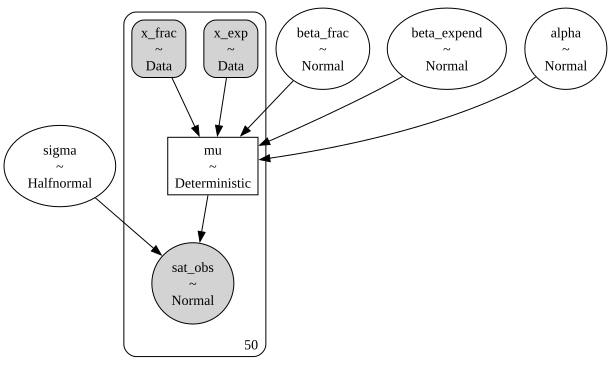

In [22]:
sat_mean = df["sat"].mean()
sat_std = df["sat"].std()

# Standardized columns
df["expend_z"] = (df["expend"] - df["expend"].mean()) / df["expend"].std()
df["frac_z"] = (df["frac"] - df["frac"].mean()) / df["frac"].std()

with pm.Model() as linear_model:
    # Priors
    alpha = pm.Normal("alpha", mu=sat_mean, sigma=100)
    beta_expend = pm.Normal("beta_expend", mu=0, sigma=sat_std)
    beta_frac = pm.Normal("beta_frac", mu=0, sigma=sat_std)
    sigma = pm.HalfNormal("sigma", sigma=25)

    # Data
    x_exp = pm.Data("x_exp", df["expend_z"].values)
    x_frac = pm.Data("x_frac", df["frac_z"].values)

    # Linear predictor
    mu = pm.Deterministic("mu", alpha + beta_expend * x_exp + beta_frac * x_frac)

    # Likelihood
    sat_obs = pm.Normal("sat_obs", mu=mu, sigma=sigma, observed=df["sat"].values)

pm.model_to_graphviz(linear_model)

### AI,

* How can I check if my priors are working nicely before sampling? More specifically, by using distribution sampling
* Briefly explain how this method works

#### Answer

The standard method is **prior predictive checking**: you sample parameter values from your priors, then simulate fake data from your model using those parameter draws — without ever touching your actual observed data. If the simulated datasets look plausible (roughly consistent with what you know about the domain), your priors are reasonable. If they produce nonsense (negative heights, probabilities way outside $[0,1]$, wildly implausible magnitudes), your priors need tightening.

##### How it works, step by step
1. Draw parameters from the prior. For each of many iterations (say, 1,000), sample a parameter set $\theta$ from your prior distribution $p\left(\theta\right)$. Example: if $\theta = \left(\beta_0, \beta_1, \sigma \right)$ with priors $\beta_0 \sim \mathcal{N}(0, 10), \beta_1 \sim \mathcal{N}(0, 5), \sigma \sim \text{HalfNormal}(2)$, draw one value of each.
2. Simulate data from the likelihood. Plug that sampled θ into your model's likelihood $p\left(y \mid\theta\right)$ and generate a synthetic dataset $y_\text{sim}$. This uses the same generative model you plan to fit, just running it "forward" instead of conditioning on real data.
3. Repeat many times. Each iteration gives you one plausible dataset under your prior beliefs. Collect them all.
4. Inspect the simulated datasets. Plot them — histograms, scatter plots, summary statistics (mean, range, extremes) — and ask: do these look like data this process could realistically produce? You're checking magnitude, sign, scale, and shape, not exact values.

##### Why this matters

Priors that look "reasonable" for a single parameter can combine to produce absurd predictions once passed through your model — this is easy to miss just by staring at the prior distributions individually. Prior predictive simulation catches this because it shows you the implied distribution of outcomes, which is what actually matters.

##### What to look for
* Too wide: simulated data includes physically impossible or absurd values (negative counts, probabilities outside [0,1], extreme outliers dominating everything)
* Too narrow: simulated data is unrealistically uniform/tight, ruling out values you know are plausible
* Right-sized: simulated data covers a sensible range — wide enough to be honest about your uncertainty, narrow enough to reflect real domain knowledge

This is distinct from posterior predictive checking, which does the same simulate-and-compare procedure but after fitting to real data, using the posterior instead of the prior — that's for checking model fit rather than checking prior sanity.

Sampling: [alpha, beta_expend, beta_frac, sat_obs, sigma]
C:\Users\gilad\PycharmProjects\applied-stats-project\.venv\Lib\site-packages\arviz_plots\plots\utils_ppc.py:68: UserWarning: This plot always uses the `observed_data` group.
Be cautious when using it for prior predictive checks.
  warn_if_prior_predictive(group)


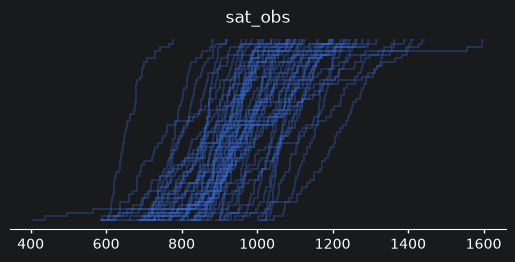

In [23]:
with linear_model:
    prior_pred = pm.sample_prior_predictive(draws=500)

# prior_pred.prior_predictive["sat_obs"].values.flatten()

az.plot_ppc_dist(prior_pred, group="prior_predictive")
# prior_pred

From PyMC documentation:
> observed_dist defaults to False, no observed data is plotted, if group is “prior_predictive”.

In [24]:
with linear_model:
    idata = pm.sample(draws=2000, chains=4, target_accept=0.9)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_expend, beta_frac, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 4 seconds.


In [25]:
print(az.summary(idata, var_names=["alpha", "beta_expend", "beta_frac", "sigma"]))

              mean    sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
alpha        965.9   4.6      960      970      7374      5234  1.00   
beta_expend   16.4   5.8      7.3       26      6887      5296  1.00   
beta_frac    -75.9   5.8      -85      -67      6453      5835  1.00   
sigma        32.64  3.39       28       38      7450      5847  1.00   

            mcse_mean mcse_sd  
alpha           0.054    0.04  
beta_expend      0.07   0.051  
beta_frac       0.072   0.052  
sigma            0.04   0.032  


### AI,

* What's ESS and r_hat? What values would indicate good performance and why?
* Read this summary: <C&P>; what can we do now?

#### Answer

##### ESS and R-hat

**R-hat (Gelman-Rubin statistic)** measures whether multiple MCMC chains have converged to the same distribution. It compares the variance between chains to the variance within chains. If chains have converged, they should be indistinguishable from each other, so this ratio should be close to 1.

* **Good:** R-hat < 1.01 (some people use 1.05 as a looser cutoff)
* **Bad:** R-hat > 1.01 suggests chains haven't mixed well — they may be stuck in different regions of the posterior, indicating non-convergence. You shouldn't trust the results if this happens.

**ESS (Effective Sample Size)** estimates how many independent samples your correlated MCMC draws are worth. MCMC samples are autocorrelated (each draw depends on the last), so 10,000 MCMC iterations might only carry the information of, say, 2,000 truly independent draws. Low ESS means your posterior estimates (especially in the tails) are noisy even if you ran lots of iterations.

* ess_bulk: effective sample size for estimating the bulk of the distribution (mean, median)
* ess_tail: effective sample size for estimating the tails (useful for credible interval endpoints)
* Good: ESS > 400 is a common rule-of-thumb minimum; higher is better. As a ratio, ESS/total draws closer to 1 means less autocorrelation (more efficient sampling).

##### Your results

Your diagnostics look excellent:


| Parameter   | R-hat | ess_bulk | ess_tail |
|-------------|-------|----------|----------|
| alpha       | 	1.00 | 7301     | 5487     |
| beta_expend | 1.00  | 6448     | 5690     |
| beta_frac   | 1.00  | 6318     | 5648     |
| sigma       | 1.00  | 7119     | 5871     |

All R-hat values are 1.00, and all ESS values are well above the 400 threshold (in the thousands). This means your chains converged and mixed well — you can trust these posterior estimates. The mcse_mean and mcse_sd (Monte Carlo standard errors) are also small relative to the posterior sd, confirming your estimates are precise.

##### What you can do now

Since sampling diagnostics are clean, you're free to move on to substantive interpretation and further checks:

1. **Interpret the coefficients**
    * beta_expend = 13.7, 89% ETI [4.3, 23] — doesn't cross zero, so there's a credible positive association between "expend" and your outcome.
    * beta_frac = -71.9, 89% ETI [-81, -63] — strongly negative and precise, credible negative association.
    * alpha = 965.9 — your intercept, presumably in the units of the outcome.
    * sigma = 32.81 — residual/observation-level standard deviation.
2. **Posterior predictive checks** — simulate data from the posterior and compare to observed data to check model fit (not just sampling quality, but whether the model itself is reasonable).
3. **Visualize** — trace plots (should look like "fuzzy caterpillars" with no trend), posterior density plots, and pair plots to check for parameter correlations (e.g., beta_expend and beta_frac might be correlated with each other).
4. **Sensitivity checks** — try different priors to see if conclusions are robust.
5. **Report results** — write up point estimates with credible intervals, and consider computing quantities of interest (e.g., predicted outcomes at specific covariate values).

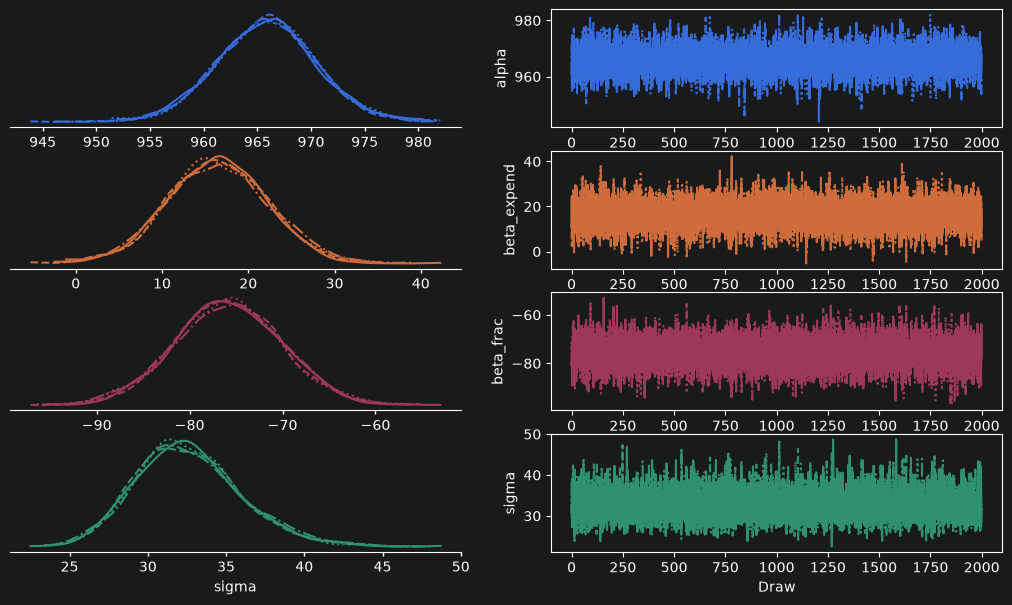

In [26]:
az.plot_trace_dist(idata, var_names=["alpha", "beta_expend", "beta_frac", "sigma"])

### AI,

* What is a posterior predictive?
* How is it useful for us?
* How do I read this plot? <C&P>

#### Answer

##### Posterior predictive (the concept)

Once you fit a Bayesian model, you don't just get a point estimate — you get a full posterior distribution over the parameters. A **posterior predictive distribution** asks: "If I used each parameter draw from that posterior to simulate a new dataset, what would those datasets look like?" You get a whole family of hypothetical datasets, each one representing "data the model thinks is plausible."

##### Why it's useful

It's the main tool for **model checking**. If your model is any good, the real, observed data should look like a "typical" draw from that family of simulated datasets. If the observed data is systematically different from what the model predicts — e.g., wrong shape, wrong spread, wrong skew — that's a sign the model is missing something (wrong likelihood, missing structure, wrong priors constraining things badly), even if the model "ran fine" and converged.

##### How to read this specific plot

This is a **posterior predictive check using empirical CDFs (ECDFs)**:

* Each thin **blue line** is the empirical CDF of one simulated dataset drawn from the posterior predictive distribution (i.e., one plausible "fake" version of `sat_obs` according to the model).
* The **white line** is the empirical CDF of your actual observed data.
* The x-axis is the SAT score value; the y-axis (unlabeled here, but implicit) runs from 0 to 1 and represents the cumulative proportion of observations ≤ that score — that's why every curve rises monotonically from bottom-left to top-right.

##### To interpret it:

* Good fit: the white line stays within the "cloud" of blue lines throughout its range — the real data looks like just another plausible draw from the model.
* Bad fit: the white line pokes outside the blue band, or has a shape (steeper, flatter, shifted, skewed differently) that the blue cloud never produces.

Looking at your plot: the white line tracks inside the blue envelope fairly well across most of the range, though it looks slightly steeper/more concentrated in the middle (~900–1050) than the bulk of blue curves, and hugs the lower edge of the band in that region. That's worth a closer look — it suggests the model may be predicting slightly more spread in the middle of the distribution than the real data shows — but it's not a dramatic misfit like the white line running way outside the band.

Sampling: [sat_obs]


Output()

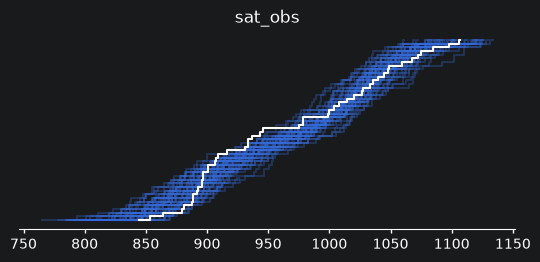

In [27]:
with linear_model:
    pm.sample_posterior_predictive(idata, extend_inferencedata=True)

az.plot_ppc_dist(idata)

### Comparison

We try to make a comparison to the OLS coefficinets.


### AI,

* How can we get a Bayesian estimator? What are the ways and their respective loss function?
* Which one is the best? Why?

#### Answer

##### Getting a Bayesian Estimator

The core idea: once you have a **posterior distribution** $\pi \left(\theta \mid x \right) \propto f \left(x\mid\theta\right) \pi(\theta)$, a Bayesian estimator $\delta(x)$ is the value that **minimizes the posterior expected loss**:

$$\delta(x) = \arg\min_{a} \mathbb{E}_{\theta|x}[L(\theta, a)]$$

Different choices of loss function L give different estimators.

1. **Squared Error Loss:**
$$L(\theta, \delta) = \left(\theta − \delta\right)^2$$
    - Bayes estimator = **posterior mean**, $\mathbb{E}\left[\theta|x\right]$
    - Most common choice; penalizes large errors heavily (quadratically)

2. **Absolute Error Loss:**
$$L(\theta, \delta) = \left|\theta - \delta\right|$$
    - Bayes estimator = **posterior median**
    - Penalizes errors linearly; more robust to outliers/skewed posteriors

3. **0–1 Loss (Zero-One Loss):**
$L(\theta, \delta) = 0$ if $\theta = \delta$, 1 otherwise (used for discrete $\theta$, or with a tolerance region in continuous cases)
    - Bayes estimator = **posterior mode**, i.e., the MAP (maximum a posteriori) estimate
    - Ignores the "size" of an error entirely — only cares whether you got it exactly right

4. **Weighted / Asymmetric Losses:**
    - **Weighted squared error:** $w(\theta)\left(\theta − \delta\right)^2$ → weighted posterior mean, useful when precision matters more in some regions of θ
    - **LINEX loss** (linear-exponential): asymmetric, penalizes over- and under-estimation differently — useful when one type of error is costlier (e.g., underestimating a risk is worse than overestimating it)
    - Bayes estimator here has a closed form involving the log of a posterior moment-generating-function-like expression

5. **General / Custom Loss:**
If L doesn't have a nice closed-form solution, you minimize the posterior expected loss numerically (e.g., via simulation from the posterior using MCMC, then optimizing over a).

---

##### Which One Is "Best"?

There's no universal answer — **it depends entirely on what a wrong estimate costs you in your actual problem.** That said, some practical guidance:

| Loss / Estimator                      | When it's preferred                                                                                                                 | Caveats                                                                                                |
|---------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------|
| **Squared error → posterior mean**    | Default choice; mathematically tractable, minimizes overall MSE                                                                     | Sensitive to outliers/heavy tails since large errors are punished disproportionately                   |
| **Absolute error → posterior median** | When you want robustness — skewed posteriors, or errors shouldn't be punished quadratically                                         | Less commonly implemented in closed form                                                               |
| **0–1 loss → MAP (posterior mode)**   | When you want the single "most probable" value; convenient in high dimensions (often reduces to a regularized optimization problem) | Ignores the shape/spread of the posterior; can behave oddly in multimodal or high-dimensional settings |
| **Asymmetric losses (e.g., LINEX)**   | When under- and over-estimation have genuinely different real-world costs (e.g., safety margins, inventory, risk exposure)          | Requires specifying asymmetry parameters, which can be subjective                                      |

##### Bottom Line

The "best" estimator isn't a property of the estimator itself — it's a property of how well the loss function matches your real decision problem. If you can specify what you're estimating and what a wrong estimate would cost you, that determines the most appropriate loss/estimator pair.

In [28]:
alpha_samples = idata.posterior["alpha"].values.flatten()
beta_expend_samples = idata.posterior["beta_expend"].values.flatten()
beta_frac_samples = idata.posterior["beta_frac"].values.flatten()

# Un-standardize: raw_coef = standardized_coef / original_std
beta_expend_raw = beta_expend_samples / df["expend"].std()
beta_frac_raw = beta_frac_samples / df["frac"].std()

alpha_raw = (
    alpha_samples
    - beta_expend_samples * df["expend"].mean() / df["expend"].std()
    - beta_frac_samples * df["frac"].mean() / df["frac"].std()
)

hdi = az.hdi(beta_expend_raw, prob=0.95)
hdi_frac = az.hdi(beta_frac_raw, prob=0.95)

comparison = pd.DataFrame(
    {
        "Method": ["OLS (frequentist)", "Bayesian posterior mean"],
        "expend coef": [adjusted.params["expend"], beta_expend_raw.mean()],
        "expend interval low": [conf_int.loc["expend"].values[0], hdi[0]],
        "expend interval high": [conf_int.loc["expend"].values[1], hdi[1]],
        "frac coef": [adjusted.params["frac"], beta_frac_raw.mean()],
        "frac interval low": [conf_int.loc["frac"].values[0], hdi_frac[0]],
        "frac interval high": [conf_int.loc["frac"].values[1], hdi_frac[1]],
    }
)

comparison

,Method,expend coef,expend interval low,expend interval high,frac coef,frac interval low,frac interval high
0,OLS (frequentist),12.286518,3.788291,20.784746,-2.850929,-3.283679,-2.418179
1,Bayesian posterior mean,12.055500,3.964030,20.685077,-2.834209,-3.253256,-2.402644


### AI,

* What's HDI?
* How is it different from CI?

#### Answer

##### What's an HDI?

**HDI = Highest Density Interval.** It's a type of *Bayesian credible interval*: a range of $\theta$ values, taken directly from the posterior distribution, that contains a given probability (e.g., 95%) of the posterior mass — and it does so using the **narrowest possible range** that achieves that.

Formally, an HDI is the interval [a, b] such that:

1. $P\left(a \le \theta \le b \mid \text{data}\right) = 0.95$ (or whatever probability you want)
2. Every point *inside* the interval has higher posterior density than every point *outside* it

That second condition is the key feature — it's what makes it the "highest density" interval rather than just any interval with the right coverage.

##### HDI vs. Equal-Tailed Credible Interval

Within the Bayesian world, there are actually two common ways to build a 95% credible interval:

| Type                      | How it's built                                         | Property                                                                        |
|---------------------------|--------------------------------------------------------|---------------------------------------------------------------------------------|
| **Equal-tailed interval** | Cut off the bottom 2.5% and top 2.5% of the posterior  | Symmetric in *probability mass*, easy to compute (just two percentiles)         |
| **HDI**                   | Find the narrowest interval containing 95% of the mass | Symmetric in *density* — always the shortest interval, always includes the mode |

For a **symmetric, unimodal posterior** (like a Gaussian), these two are identical. They diverge when the posterior is **skewed** or **multimodal**:

- On a **skewed** posterior, the equal-tailed interval can exclude the mode (the most probable value!) and include a needlessly wide low-density tail. The HDI won't do that — it's always the tightest possible band.
- On a **multimodal** posterior, the HDI can become **disjoint** — e.g., two separate chunks like $[1, 3] \cup [7, 9]$ — correctly reflecting that θ is either in one cluster or the other, with nothing in between. An equal-tailed interval can't do this; it's always a single contiguous range, so it would misleadingly include the low-probability valley.

##### HDI vs. Frequentist Confidence Interval (CI)

This is the deeper distinction — different philosophy, not just different math.

|                                | HDI (Bayesian)                                                               | CI (Frequentist)                                                                                                                                                          |
|--------------------------------|------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **What's random**              | θ is treated as a random variable; data is fixed                             | θ is fixed (unknown constant); data is random                                                                                                                             |
| **What it's built from**       | The posterior distribution p(θ \| data)                                      | The sampling distribution of an estimator, imagining repeated experiments                                                                                                 |
| **Interpretation**             | "Given the data I observed, there's a 95% probability θ falls in this range" | "If I repeated this experiment many times, 95% of the intervals constructed this way would contain the true θ" — you *cannot* say "95% probability θ is in this interval" |
| **Requires a prior?**          | Yes                                                                          | No                                                                                                                                                                        |
| **Can be asymmetric/disjoint** | Yes, naturally follows the posterior shape                                   | Standard CIs are typically symmetric or based on a fixed procedure                                                                                                        |

The interpretation difference is the one people trip up on most: a 95% CI does **not** mean "95% probability the true value is in this interval" — that's a Bayesian statement. A 95% CI means "the procedure used to generate this interval captures the true value 95% of the time across repeated experiments." The HDI is the one that actually gives you the intuitive probability statement people usually *want* when they see an interval.

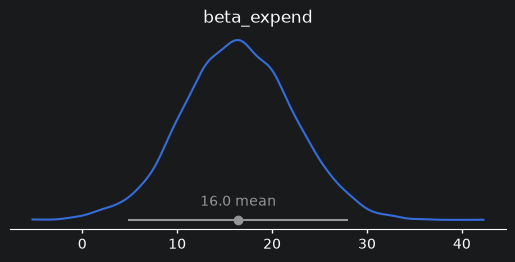

In [29]:
az.plot_dist(idata, var_names=["beta_expend"], ci_prob=0.95)

In [30]:
posterior_mean = beta_expend_samples.mean()
posterior_median = np.median(beta_expend_samples)

# MAP via kernel density estimate (no closed form for an arbitrary posterior)
kde = stats.gaussian_kde(beta_expend_samples)
x_grid = np.linspace(beta_expend_samples.min(), beta_expend_samples.max(), 2000)
posterior_map = x_grid[np.argmax(kde(x_grid))]

print(f"Posterior mean:   {posterior_mean:.4f}")
print(f"Posterior median: {posterior_median:.4f}")
print(f"Posterior MAP:    {posterior_map:.4f}")

Posterior mean:   16.4293
Posterior median: 16.3922
Posterior MAP:    16.3609


### Regularization

In [33]:
X_vif = sm.add_constant(df[["expend", "frac"]])

vif_data = pd.DataFrame(
    {
        "Variable": X_vif.columns,
        "VIF": [VIF(X_vif.values, i) for i in range(X_vif.shape[1])],
    }
)
vif_data

,Variable,VIF
0,const,22.621574
1,expend,1.541324
2,frac,1.541324


OLS coefficients unstable under collinearity?

In [37]:
boot_expend = np.empty(n_boot)
boot_frac = np.empty(n_boot)

for i in range(n_boot):
    sample = df.sample(n=len(df), replace=True, random_state=rng.integers(1e9))
    X_boot = sm.add_constant(sample[["expend", "frac"]])
    boot_model = sm.OLS(sample["sat"], X_boot).fit()
    boot_expend[i] = boot_model.params["expend"]
    boot_frac[i] = boot_model.params["frac"]

print(f"Bootstrap SD of expend coef: {boot_expend.std():.3f}")
print(f"Bootstrap SD of frac coef:   {boot_frac.std():.3f}")
print(
    f"Correlation between bootstrapped expend and frac coefs: {np.corrcoef(boot_expend, boot_frac)[0,1]:.3f}"
)

Bootstrap SD of expend coef: 4.268
Bootstrap SD of frac coef:   0.236
Correlation between bootstrapped expend and frac coefs: -0.667


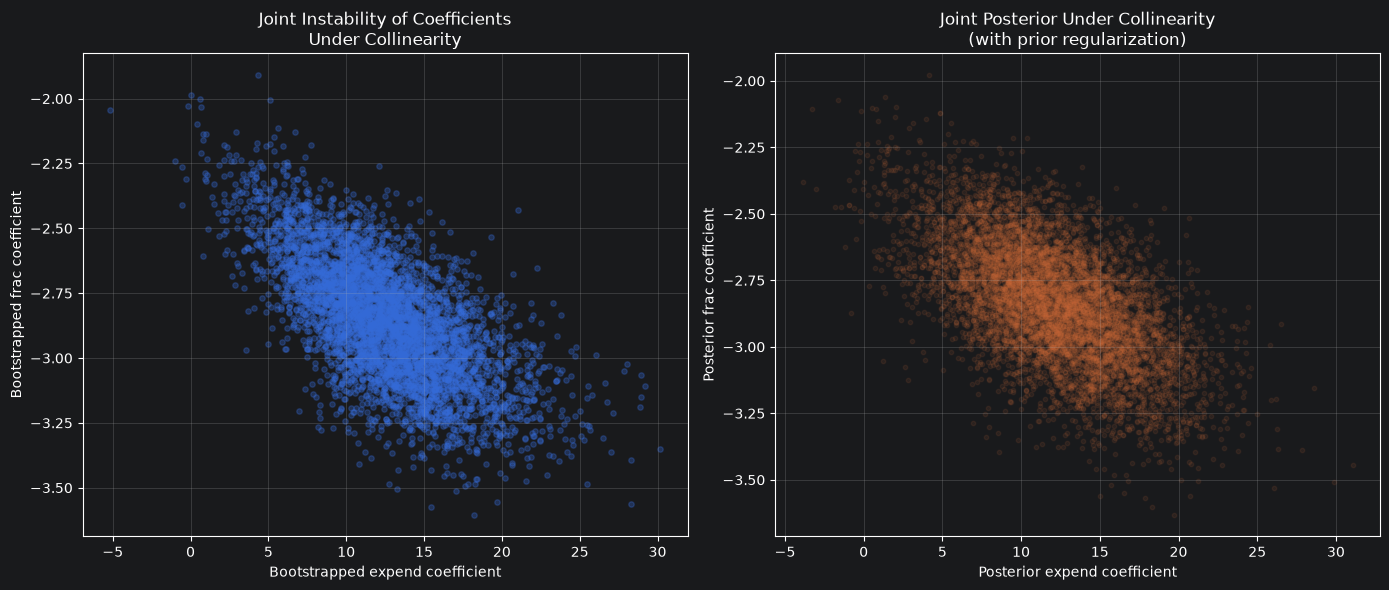

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bootstrap
axes[0].scatter(boot_expend, boot_frac, alpha=0.3, s=15)
axes[0].set_xlabel("Bootstrapped expend coefficient")
axes[0].set_ylabel("Bootstrapped frac coefficient")
axes[0].set_title("Joint Instability of Coefficients\nUnder Collinearity")
axes[0].grid(alpha=0.3)

# Posterior
axes[1].scatter(beta_expend_raw, beta_frac_raw, alpha=0.1, s=10, color="C1")
axes[1].set_xlabel("Posterior expend coefficient")
axes[1].set_ylabel("Posterior frac coefficient")
axes[1].set_title("Joint Posterior Under Collinearity\n(with prior regularization)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
print(f"Bootstrap coefficient covariance:\n{np.cov(boot_expend, boot_frac)}")
print(f"\nPosterior coefficient covariance:\n{np.cov(beta_expend_raw, beta_frac_raw)}")

Bootstrap coefficient covariance:
[[18.21801591 -0.67226014]
 [-0.67226014  0.05571573]]

Posterior coefficient covariance:
[[18.15640381 -0.54302182]
 [-0.54302182  0.04649303]]


In [ ]:
X_ridge = df[['expend_z', 'frac_z']].values
y_ridge = df['sat'].values

# Try a couple of alpha (penalty) values
for alpha_ridge in [0.1, 1, 10]:
    ridge_model = Ridge(alpha=alpha_ridge)
    ridge_model.fit(X_ridge, y_ridge)
    print(f"Ridge alpha={alpha_ridge}: expend_z coef={ridge_model.coef_[0]:.3f}, frac_z coef={ridge_model.coef_[1]:.3f}")

print(f"\nOLS (no penalty): expend_z coef={?}")  # your original OLS coefficient on standardized predictors, for comparison

## Hierarchical Models

In [45]:
df["region_idx"] = df["region"].astype("category").cat.codes
region_names = df["region"].astype("category").cat.categories.tolist()
n_regions = len(region_names)

print(f"{n_regions} regions: {region_names}")
df.groupby("region").size()

9 regions: ['East North Central', 'East South Central', 'Middle Atlantic', 'Mountain', 'New England', 'Pacific', 'South Atlantic', 'West North Central', 'West South Central']


region
East North Central    5
East South Central    4
Middle Atlantic       3
Mountain              8
New England           6
Pacific               5
South Atlantic        8
West North Central    7
West South Central    4
dtype: int64

"Frequentist" approach: Calculate means and std by groups

In [46]:
no_pooling_results = []
for region in region_names:
    sub = df[df["region"] == region]
    no_pooling_results.append(
        {
            "region": region,
            "n": len(sub),
            "mean_sat": sub["sat"].mean(),
            "sd_sat": sub["sat"].std(ddof=1) if len(sub) > 1 else np.nan,
        }
    )

no_pooling_df = pd.DataFrame(no_pooling_results)
print(no_pooling_df)

               region  n     mean_sat     sd_sat
0  East North Central  5  1002.200000  76.234507
1  East South Central  4  1026.000000  18.565200
2     Middle Atlantic  3   890.000000   9.165151
3            Mountain  8   990.125000  48.060787
4         New England  6   905.833333  16.092441
5             Pacific  5   921.800000  24.913852
6      South Atlantic  8   885.750000  29.528437
7  West North Central  7  1073.428571  24.089120
8  West South Central  4   986.500000  63.021160


In [47]:
complete_pooling_mean = df["sat"].mean()
complete_pooling_sd = df["sat"].std(ddof=1)
print(
    f"Complete pooling: mean={complete_pooling_mean:.2f}, sd={complete_pooling_sd:.2f}"
)

Complete pooling: mean=965.92, sd=74.82


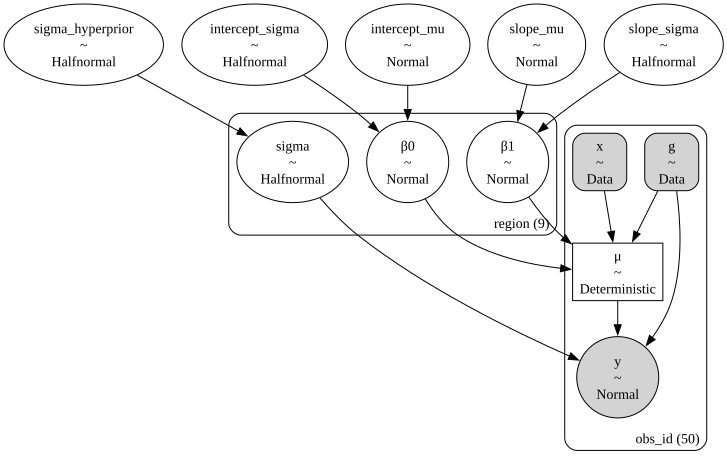

In [57]:
coords = {"region": region_names, "obs_id": df.index}

with pm.Model(coords=coords) as hierarchical:
    # Hyperpriors
    intercept_mu = pm.Normal("intercept_mu", mu=df['sat'].mean(), sigma=50)
    intercept_sigma = pm.HalfNormal("intercept_sigma", sigma=50)
    slope_mu = pm.Normal("slope_mu", mu=0, sigma=sat_std)
    slope_sigma = pm.HalfNormal("slope_sigma", sigma=sat_std)
    sigma_hyperprior = pm.HalfNormal("sigma_hyperprior", sigma=25)

    # Region-level priors
    sigma = pm.HalfNormal("sigma", sigma=sigma_hyperprior, dims="region")
    β0 = pm.Normal("β0", intercept_mu, sigma=intercept_sigma, dims="region")
    β1 = pm.Normal("β1", slope_mu, sigma=slope_sigma, dims="region")

    # Data containers
    x = pm.Data("x", df['expend_z'].values, dims="obs_id")
    g = pm.Data("g", df['region_idx'].values, dims="obs_id")

    # Linear model
    μ = pm.Deterministic("μ", β0[g] + β1[g] * x, dims="obs_id")

    # Likelihood
    pm.Normal("y", mu=μ, sigma=sigma[g], observed=df['sat'].values, dims="obs_id")

pm.model_to_graphviz(hierarchical)

In [62]:
with hierarchical:
    idata_h = pm.sample(300, chains=4, target_accept=0.9)

az.summary(idata_h, var_names=["~μ"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_mu, intercept_sigma, slope_mu, slope_sigma, sigma_hyperprior, sigma, β0, β1]


Output()

Sampling 4 chains for 1_000 tune and 300 draw iterations (4_000 + 1_200 draws total) took 6 seconds.
There were 77 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept_mu,958,21,930,990,719,687,1.00,0.78,0.65
slope_mu,-5,15,-31,17,504,551,1.00,0.7,0.66
β0[East North Central],988,29,940,1000,522,526,1.00,1.3,1
β0[East South Central],994,24,960,1000,219,328,1.02,1.6,1.3
β0[Middle Atlantic],891,30,860,950,354,306,1.00,1.8,1.7
β0[Mountain],975,21,940,1000,590,564,1.01,0.88,0.66
β0[New England],915,15,890,940,382,327,1.02,0.88,0.95
β0[Pacific],922,16,900,950,495,481,1.01,0.71,0.86
β0[South Atlantic],889.6,10,870,910,840,606,1.00,0.36,0.34
β0[West North Central],1064,14,1000,1100,596,387,1.01,0.59,0.6


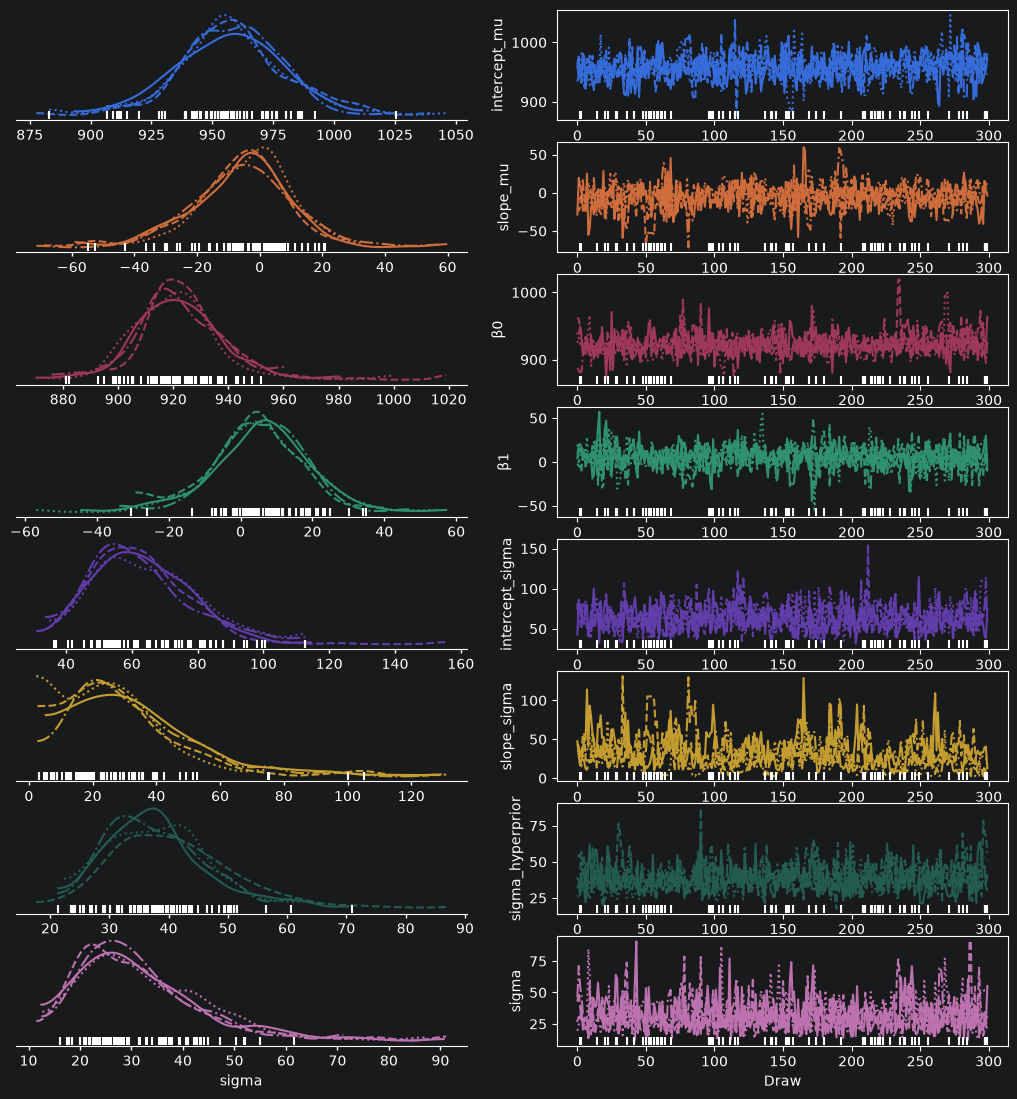

In [63]:
az.plot_trace_dist(idata_h, var_names=["~μ"], coords={"region": "Pacific"})

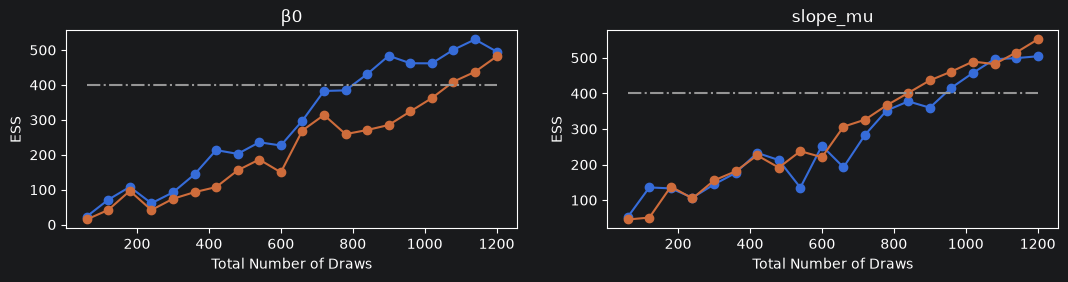

In [64]:
az.plot_ess_evolution(idata_h, var_names=["β0", "slope_mu"], coords={"region": "Pacific"})